In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
FILTER_SE_GENES = False # filter for only genes with SE events
SINGLE_COUNT_GENES = True # filter out duplicates of genes with multiple SE events

In [15]:
predictions = pd.read_csv('trained_models/2025-06-03-13/fold_1_EPInformer-PE-Activity-HiC.preTrainedConv.4base.64dim.3Trans.4head.TrueBN.TrueLN.TrueFeat.3extraFeat.60enh.K562.transcript_predictions.csv')
predictions = predictions.rename(columns={'Unnamed: 0': 'gene_id'})
predictions

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000196388,1.317705,-0.823909,-0.056244,1.0,1
1,ENSG00000164051,1.296980,1.109916,-0.054778,1.0,1
2,ENSG00000064102,1.350277,1.707059,0.076183,1.0,1
3,ENSG00000064102,1.348352,1.707059,0.076377,1.0,1
4,ENSG00000064102,1.344633,1.707059,0.074072,1.0,1
...,...,...,...,...,...,...
2480,ENSG00000106397,1.369114,1.317646,0.128588,1.0,1
2481,ENSG00000106397,1.369036,1.317646,0.128540,1.0,1
2482,ENSG00000106397,1.369056,1.317646,0.127936,1.0,1
2483,ENSG00000134769,1.253749,0.045323,-0.155854,1.0,1


In [16]:
if FILTER_SE_GENES:
    # filter predictions to the ones we have SE events for
    se_events = pd.read_csv('data/psi_response.csv')
    se_events = se_events[se_events['event_id'].str.contains(';SE:')]
    se_genes = set(se_events['gene_id'].unique())

    # filter down predictions to only those genes
    predictions_filtered = predictions[predictions['gene_id'].isin(se_genes)]
    len(predictions_filtered)

In [17]:
if SINGLE_COUNT_GENES:
    # filter the predictions such that for one gene, we keep the first prediction for it
    predictions_filtered = predictions.drop_duplicates(subset=['gene_id'], keep='first')

In [18]:
if not FILTER_SE_GENES and not SINGLE_COUNT_GENES:
    predictions_filtered = predictions

In [19]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Prediction (Pearson R: {pearsonR:.2f})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    

<Figure size 600x600 with 0 Axes>

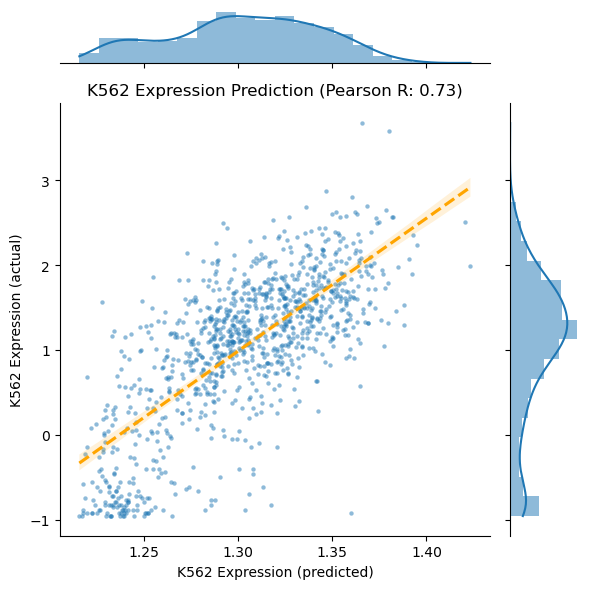

In [20]:
plot_predictions(predictions_filtered, cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

<Figure size 600x600 with 0 Axes>

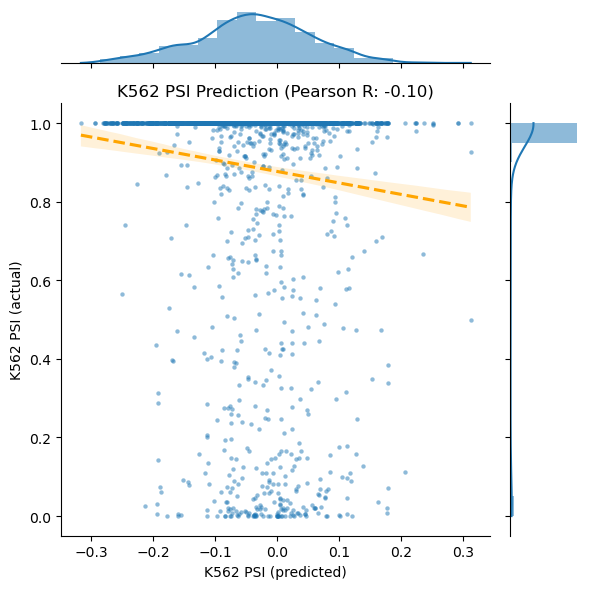

In [21]:
plot_predictions(predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()